# Customer Churn Prediction — Telecom
**Goal:** Predict which customers are likely to churn and identify the key drivers.

**Business Impact:** Reducing churn by 5% can increase profits by 25–95% (Harvard Business Review).

### Notebook Structure
1. Data Loading & Overview
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing
4. Model Training & Comparison
5. SHAP Explainability
6. Business Recommendations

In [2]:
!pip install xgboost shap streamlit -q

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, precision_recall_curve,
                              ConfusionMatrixDisplay)
from xgboost import XGBClassifier
import shap

plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = ['#2ecc71', '#e74c3c']
print('Libraries loaded successfully')

Libraries loaded successfully


## 1. Data Loading & Overview

In [4]:
# Using IBM Telco Customer Churn dataset (public domain)
# Can be loaded directly from GitHub raw URL
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url)

print(f'Dataset shape: {df.shape}')
print(f'Churn rate: {df["Churn"].value_counts(normalize=True)["Yes"]:.1%}')
df.head()

Dataset shape: (7043, 21)
Churn rate: 26.5%


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
print('=== Data Types ===')
print(df.dtypes)
print('\n=== Missing Values ===')
print(df.isnull().sum()[df.isnull().sum() > 0])
print('\n=== Basic Statistics ===')
df.describe()

=== Data Types ===
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

=== Missing Values ===
Series([], dtype: int64)

=== Basic Statistics ===


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 2. Exploratory Data Analysis

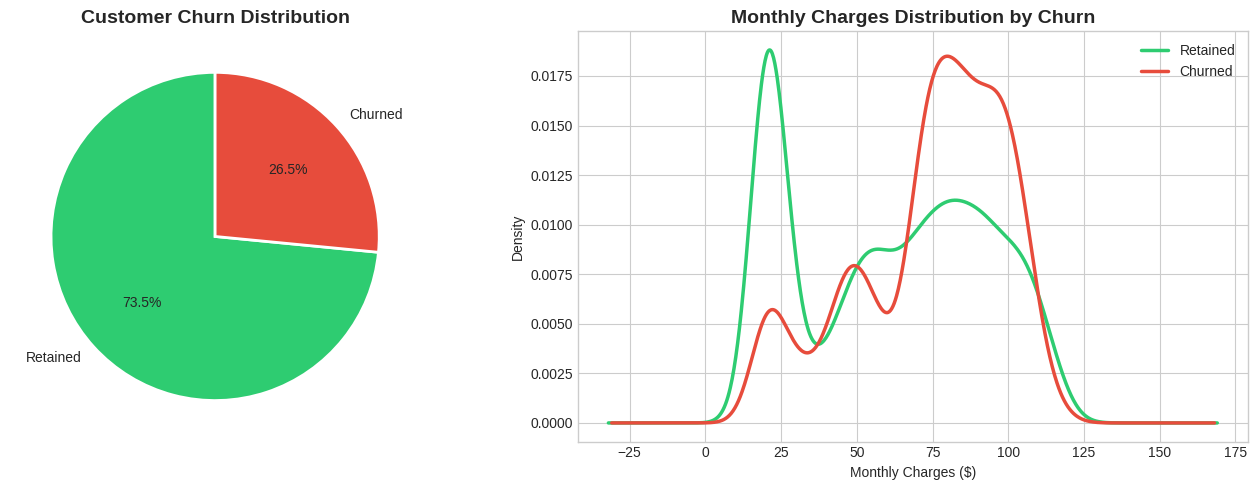

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Churn distribution
churn_counts = df['Churn'].value_counts()
axes[0].pie(churn_counts, labels=['Retained', 'Churned'],
            colors=PALETTE, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Customer Churn Distribution', fontsize=14, fontweight='bold')

# Monthly charges by churn
df.groupby('Churn')['MonthlyCharges'].plot(kind='kde', ax=axes[1],
    color=dict(zip(['No','Yes'], PALETTE)), linewidth=2.5)
axes[1].set_title('Monthly Charges Distribution by Churn', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Monthly Charges ($)')
axes[1].legend(['Retained', 'Churned'])

plt.tight_layout()
plt.savefig('churn_overview.png', dpi=150, bbox_inches='tight')
plt.show()

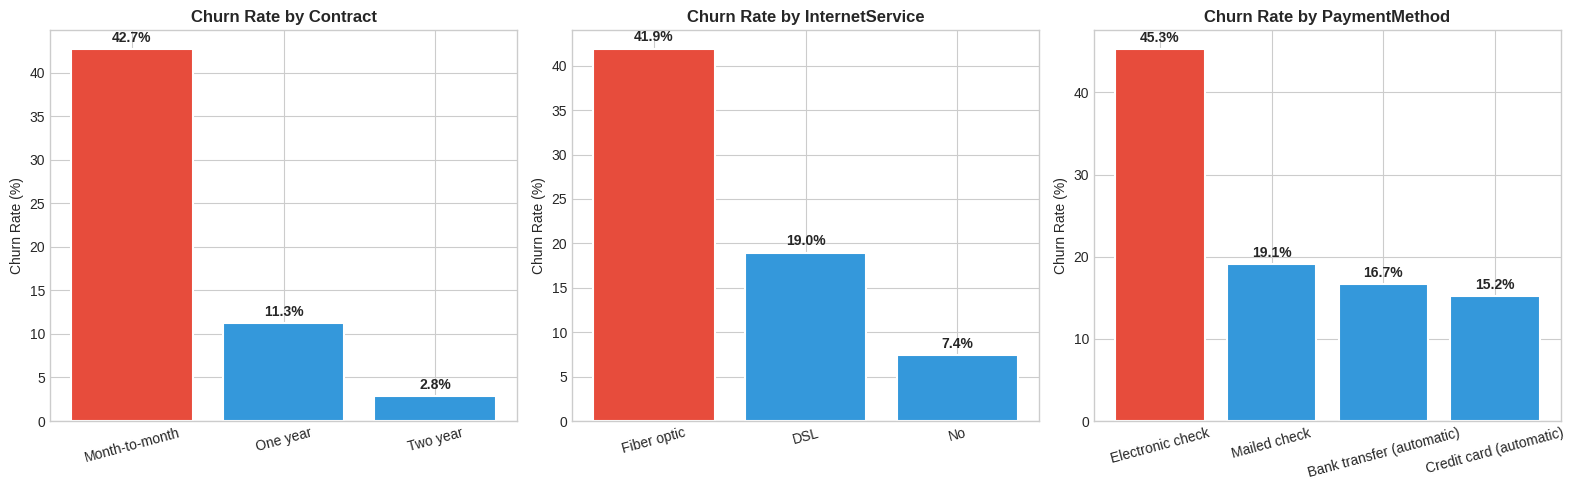

Key insight: Month-to-month contracts churn significantly more than annual contracts


In [8]:
# Churn rate by contract type — strong business insight
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

categorical_features = ['Contract', 'InternetService', 'PaymentMethod']
for ax, feat in zip(axes, categorical_features):
    churn_rate = df.groupby(feat)['Churn'].apply(
        lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False)
    bars = ax.bar(churn_rate.index, churn_rate.values,
                  color=['#e74c3c' if v > 20 else '#3498db' for v in churn_rate.values],
                  edgecolor='white', linewidth=1.5)
    ax.set_title(f'Churn Rate by {feat}', fontweight='bold')
    ax.set_ylabel('Churn Rate (%)')
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, churn_rate.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('churn_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
print('Key insight: Month-to-month contracts churn significantly more than annual contracts')

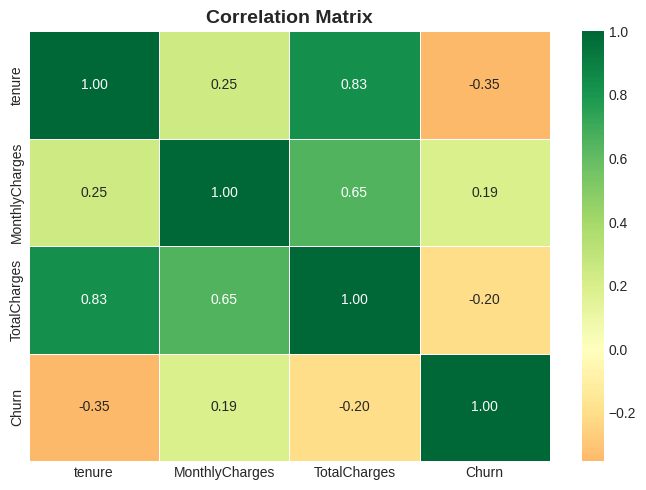

In [9]:
# Correlation heatmap of numeric features
numeric_df = df[['tenure', 'MonthlyCharges', 'TotalCharges']].copy()
numeric_df['TotalCharges'] = pd.to_numeric(numeric_df['TotalCharges'], errors='coerce')
numeric_df['Churn'] = (df['Churn'] == 'Yes').astype(int)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Data Preprocessing

In [10]:
df_clean = df.copy()

# Fix TotalCharges (whitespace → NaN)
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
df_clean['TotalCharges'].fillna(df_clean['TotalCharges'].median(), inplace=True)

# Drop customerID — not a feature
df_clean.drop('customerID', axis=1, inplace=True)

# Encode binary columns
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
               'PaperlessBilling', 'Churn']
for col in binary_cols:
    df_clean[col] = LabelEncoder().fit_transform(df_clean[col])

# One-hot encode remaining categoricals
cat_cols = df_clean.select_dtypes(include='object').columns.tolist()
df_clean = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)

print(f'Final feature count: {df_clean.shape[1] - 1}')
print(f'Samples: {len(df_clean)}')
df_clean.head()

Final feature count: 30
Samples: 7043


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


In [11]:
X = df_clean.drop('Churn', axis=1)
y = df_clean['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train size: {len(X_train)} | Test size: {len(X_test)}')
print(f'Churn rate in train: {y_train.mean():.1%} | test: {y_test.mean():.1%}')

Train size: 5634 | Test size: 1409
Churn rate in train: 26.5% | test: 26.5%


## 4. Model Training & Comparison

In [12]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'XGBoost':             XGBClassifier(n_estimators=200, learning_rate=0.05,
                                         max_depth=5, random_state=42,
                                         eval_metric='logloss', verbosity=0),
}

results = {}
for name, model in models.items():
    X_tr = X_train_sc if name == 'Logistic Regression' else X_train
    X_te = X_test_sc  if name == 'Logistic Regression' else X_test
    model.fit(X_tr, y_train)
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    results[name] = {
        'model': model, 'y_pred': y_pred, 'y_proba': y_proba,
        'roc_auc': roc_auc_score(y_test, y_proba),
        'report': classification_report(y_test, y_pred, output_dict=True)
    }
    print(f'{name}: ROC-AUC = {results[name]["roc_auc"]:.4f}')

Logistic Regression: ROC-AUC = 0.8416
Random Forest: ROC-AUC = 0.8243
XGBoost: ROC-AUC = 0.8423


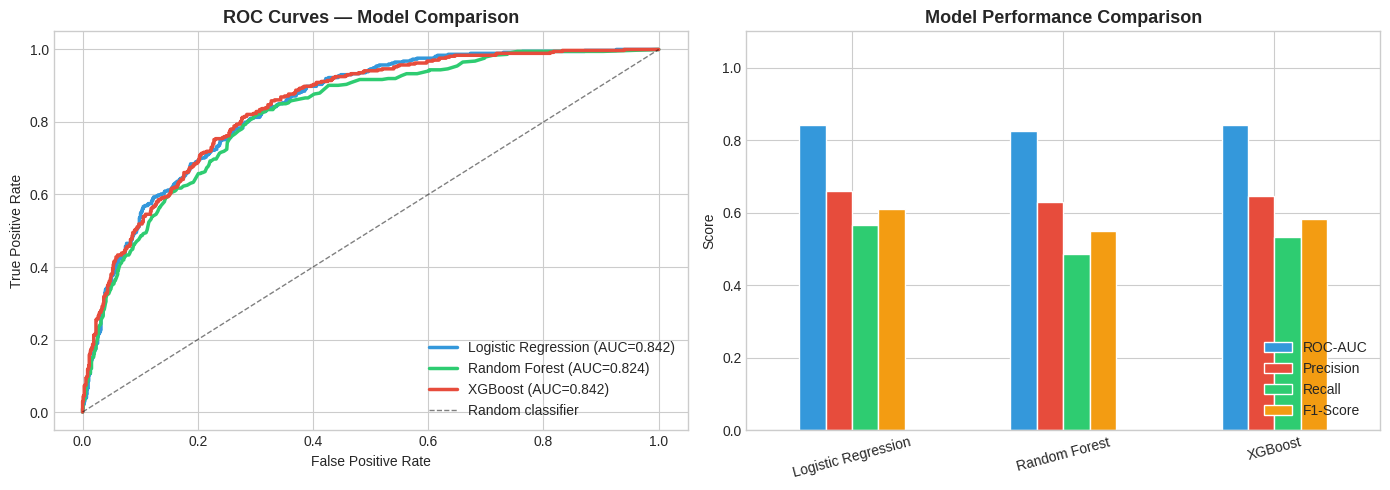

In [14]:
# ROC Curves comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#3498db', '#2ecc71', '#e74c3c']

for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={res['roc_auc']:.3f})",
                 color=color, linewidth=2.5)
axes[0].plot([0,1],[0,1],'k--', linewidth=1, alpha=0.5, label='Random classifier')
axes[0].set_title('ROC Curves — Model Comparison', fontweight='bold', fontsize=13)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

# Metric comparison bar chart
metrics_df = pd.DataFrame({
    name: {
        'ROC-AUC':   res['roc_auc'],
        'Precision': res['report']['1']['precision'],
        'Recall':    res['report']['1']['recall'],
        'F1-Score':  res['report']['1']['f1-score'],
    } for name, res in results.items()
}).T
metrics_df.plot(kind='bar', ax=axes[1], color=['#3498db','#e74c3c','#2ecc71','#f39c12'],
                edgecolor='white', linewidth=1)
axes[1].set_title('Model Performance Comparison', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Score')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15)
axes[1].set_ylim(0, 1.1)
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. SHAP Explainability — Why Does a Customer Churn?

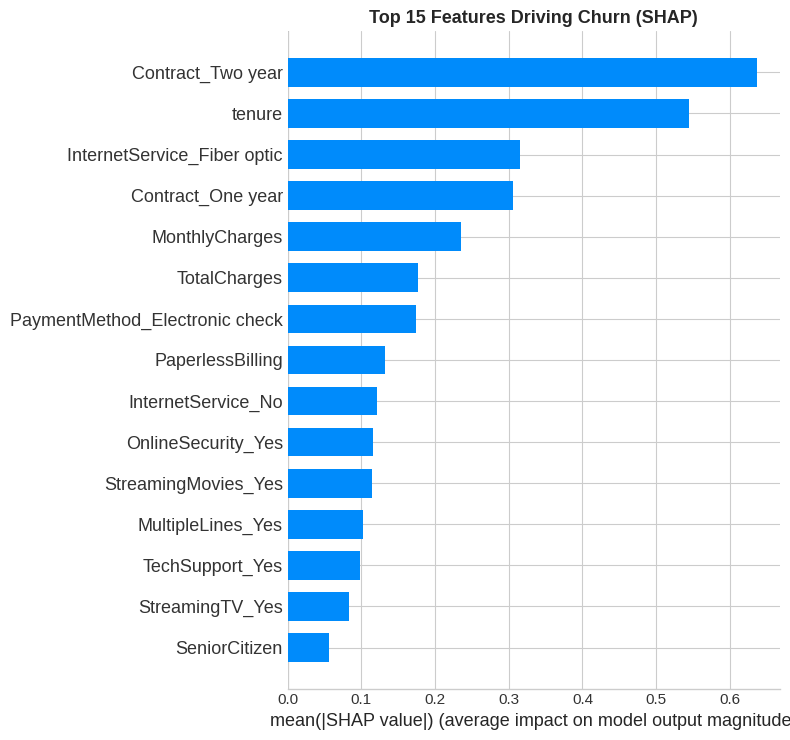

In [15]:
# SHAP values for XGBoost (best model)
best_model = results['XGBoost']['model']
explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, plot_type='bar',
                  max_display=15, show=False)
plt.title('Top 15 Features Driving Churn (SHAP)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

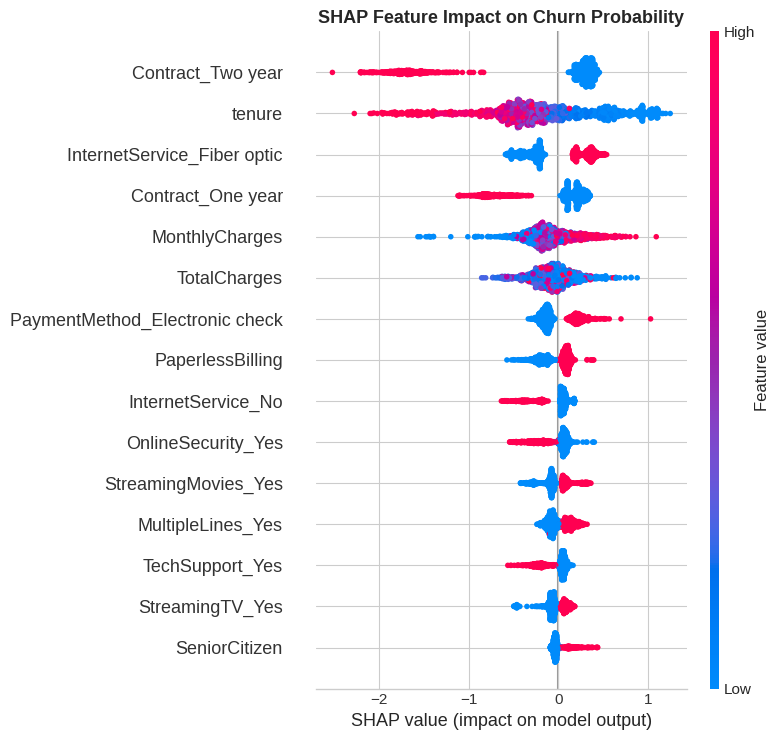

In [16]:
# SHAP beeswarm — shows direction of impact
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, max_display=15, show=False)
plt.title('SHAP Feature Impact on Churn Probability', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Business Recommendations

Based on the analysis:

| Finding | Recommendation |
|---|---|
| Month-to-month contracts churn 3× more | Offer incentives to switch to annual contracts |
| High monthly charges = higher churn | Introduce loyalty pricing tiers |
| Low tenure customers churn more | Create onboarding loyalty programme for first 12 months |
| Fibre optic users churn more than DSL | Investigate service quality issues with fibre |
| No tech support = higher churn | Bundle tech support into standard plans |

**Model recommendation:** Use XGBoost in production with a threshold of ~0.35 (optimise for recall to catch more churners), triggering retention campaigns for high-risk customers.